# Tree reconstruction with SCITE

**[SCITE](https://github.com/cbg-ethz/SCITE)** (Jahn, Kuipers & Beerenwinkel 2016) reconstructs a
tumour's mutation tree from single-cell genotypes. That problem is hard for one reason: single-cell
data is *noisy*. Allelic dropout loses real mutations, and false positives invent them, so the
observed matrix is a corrupted view of the genotypes and the tree has to be inferred through that
noise rather than read off.

`iscc` is a good test of exactly that, because it knows the true tree and it knows precisely how the
matrix was corrupted.

| file | what it is | who sees it |
|---|---|---|
| `sc/P*.csv` | one noisy events × cells genotype matrix per patient | the tool |
| `truth_trees.csv` | each patient's true mutation tree | **scoring only** |

Generated once by `python validation/make_analysis_data.py --only treemhn`; the true trees and the
planted network are laid out in
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb).

**On subprocesses.** Every other notebook in this section runs its tool in-process, in the tool's own
kernel. SCITE has no library API at all — it is a C++ command-line program, and its CLI *is* its
interface, so calling it is using it as intended. It runs in its own kernel (`Python (iscc-scite)`)
with the compiled binary alongside.

**Why this notebook exists.** The trees
[TreeMHN](tool_treemhn_R.ipynb) reads are the ones reconstructed here. Handing TreeMHN iscc's own
trees would make that benchmark vacuous — it would be estimating rates from the topology it is
supposed to infer.

In [1]:
import json, os, re, subprocess, sys, tempfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import graphviz

SCITE = os.path.join(sys.prefix, "bin", "scite")
DATA  = os.path.join("..", "analysis_data", "treemhn")
assert os.path.exists(SCITE), f"scite binary not found at {SCITE}"
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only treemhn")

meta = json.load(open(os.path.join(DATA, "meta.json")))
sc_dir = os.path.join(DATA, "sc")
patients = sorted(os.listdir(sc_dir), key=lambda f: int(f[1:-4]))
mats = {f[:-4]: pd.read_csv(os.path.join(sc_dir, f), index_col=0) for f in patients}
events = list(next(iter(mats.values())).index)

FD, AD = meta["scite_fd"], meta["scite_ad"]
print(f"{len(mats)} patients, {len(events)} events, "
      f"{next(iter(mats.values())).shape[1]} cells sequenced each")
print(f"genotyping error rates the matrices were corrupted with: "
      f"false positive {FD}, dropout {AD}")

36 patients, 4 events, 500 cells sequenced each
genotyping error rates the matrices were corrupted with: false positive 0.01, dropout 0.2


## What SCITE is given

One patient's matrix: a row per event, a column per cell, `1` where the event was called. A fifth of
the real calls are missing, so the block structure a clone should produce is visibly ragged. This is
the input — nothing here has seen the true tree.

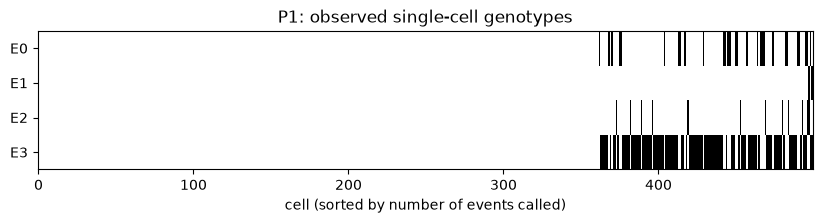

per-event call rate: {'E0': np.float64(0.06), 'E1': np.float64(0.0), 'E2': np.float64(0.02), 'E3': np.float64(0.2)}


In [2]:
P = "P1"
M = mats[P].values
fig, ax = plt.subplots(figsize=(10, 1.8))
ax.imshow(M[:, np.argsort(M.sum(0), kind="stable")], aspect="auto", cmap="Greys",
          interpolation="nearest")
ax.set_yticks(range(len(events))); ax.set_yticklabels(events)
ax.set_xlabel("cell (sorted by number of events called)")
ax.set_title(f"{P}: observed single-cell genotypes")
plt.show()

print("per-event call rate:", dict(zip(events, M.mean(1).round(2))))

## Running SCITE

SCITE is told the same error rates the data was generated with — which is what a study does after
estimating them from its own controls — and run as one MCMC chain per patient. Its output is a
GraphViz tree, which is what the figures below render: SCITE's own format, drawn by GraphViz.

P1 reconstructed tree: Root->E0 , E2->E1 , Root->E2 , Root->E3


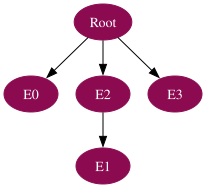

In [3]:
def run_scite(obs, names, fd=FD, ad=AD, seed=1, chain_length=100_000):
    """Run SCITE on an events x cells matrix; return its ML tree as GraphViz source."""
    n, m = obs.shape
    with tempfile.TemporaryDirectory() as tmp:
        mat, nam = os.path.join(tmp, "sc.txt"), os.path.join(tmp, "names.txt")
        np.savetxt(mat, obs, fmt="%d")
        open(nam, "w").write("\n".join(names) + "\n")
        proc = subprocess.run(
            [SCITE, "-i", mat, "-n", str(n), "-m", str(m), "-r", "1", "-l", str(chain_length),
             "-fd", str(fd), "-ad", str(ad), "-names", nam,
             "-max_treelist_size", "1", "-seed", str(seed)],
            capture_output=True, text=True, cwd=tmp)
        if proc.returncode != 0:
            raise RuntimeError(proc.stderr[-400:])
        gv = sorted(f for f in os.listdir(tmp) if f.endswith(".gv"))
        return open(os.path.join(tmp, gv[0])).read()

def edges(gv):
    return [(m.group(1), m.group(2))
            for m in (re.match(r"\s*(\S+)\s*->\s*(\S+)\s*;", l) for l in gv.splitlines()) if m]

gv1 = run_scite(mats[P].values, events, seed=1)
print(f"{P} reconstructed tree:", " , ".join(f"{a}->{b}" for a, b in edges(gv1)))
graphviz.Source(gv1)

## The trees, patient by patient

Each patient gets its own tree, and they differ — that variation across patients *is* the signal
TreeMHN reads downstream. These are drawn straight from SCITE's GraphViz output.

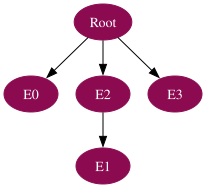

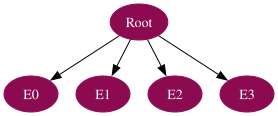

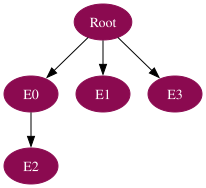

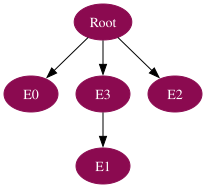

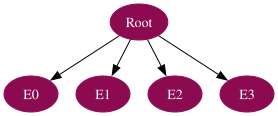

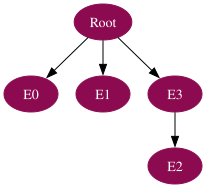

In [4]:
from IPython.display import display

gvs = {p: run_scite(m.values, events, seed=1 + i) for i, (p, m) in enumerate(mats.items())}

for p in list(gvs)[:6]:
    src = graphviz.Source(gvs[p])
    src.graph_attr = {"label": p, "labelloc": "t", "fontsize": "18"}
    display(src)

## Scoring the reconstruction

Now the truth. A mutation tree is a set of parent → child event pairs, so the reconstruction is
scored on how many of the true pairs SCITE recovered and how many it invented — recall and precision
over edges, across the cohort.

Two things have to be got right for that comparison to be fair.

**Score only the events a patient actually has.** SCITE places *every* event somewhere in the tree,
including ones the patient never acquired; those placements are forced by the model, not claims about
the data. An event counts as detected here only if it is called in more cells than false positives
alone would explain — `fd·m + 3√(fd(1−fd)m)`, three standard deviations above the noise floor.

**Compare on events, not node ids, after contracting to the detected set.** Each retained event is
linked to its nearest retained ancestor in both trees, so an intermediate event that neither tree
could see does not count against either.

In [5]:
truth = pd.read_csv(os.path.join(DATA, "truth_trees.csv"))
name = lambda m: "Root" if int(m) == 0 else events[int(m) - 1]

def detected(obs):
    """Events called in more cells than the false-positive rate alone would explain."""
    m = obs.shape[1]
    floor = FD * m + 3 * np.sqrt(FD * (1 - FD) * m)
    return {events[i] for i in range(len(events)) if obs[i].sum() > floor}

def truth_edges(df, keep):
    """True (parent, child) event pairs, contracted to `keep`.

    The true tree is a TRIE over the realised clone orders, so one event can sit at several nodes
    with different parents — the walk up therefore has to run over node ids, not event names.
    """
    mut = dict(zip(df["Node_ID"], df["Mutation_ID"]))
    par = dict(zip(df["Node_ID"], df["Parent_ID"]))
    out = set()
    for nid in df["Node_ID"]:
        if nid == par[nid] or name(mut[nid]) not in keep:
            continue
        a = par[nid]
        while mut[a] != 0 and name(mut[a]) not in keep:
            a = par[a]
        out.add((name(mut[a]), name(mut[nid])))
    return out

def scite_edges(gv, keep):
    """SCITE's (parent, child) pairs, contracted the same way."""
    par = {c: p for p, c in edges(gv)}
    out = set()
    for c in par:
        if c not in keep:
            continue
        a = par[c]
        while a != "Root" and a not in keep:
            a = par[a]
        out.add((a, c))
    return out

rec, prec, perfect, n = [], [], 0, 0
for pid, df in truth.groupby("Patient_ID"):
    key = f"P{pid}"
    if key not in gvs:
        continue
    keep = detected(mats[key].values)
    T, S = truth_edges(df, keep), scite_edges(gvs[key], keep)
    if not T:
        continue
    n += 1
    rec.append(len(T & S) / len(T))
    prec.append(len(T & S) / max(len(S), 1))
    perfect += int(T == S)

print(f"SCITE vs iscc's true trees, over {n} patients with a detectable event")
print(f"  edge recall    {np.mean(rec):.2f}   (of the true parent->child pairs, how many were found)")
print(f"  edge precision {np.mean(prec):.2f}   (of the pairs it reported, how many are real)")
print(f"  exactly right: {perfect} of {n} patients")

SCITE vs iscc's true trees, over 36 patients with a detectable event
  edge recall    0.84   (of the true parent->child pairs, how many were found)
  edge precision 0.94   (of the pairs it reported, how many are real)
  exactly right: 22 of 36 patients


## What to take from it

The trees above are the input to
[Recovering progression constraints with TreeMHN](tool_treemhn_R.ipynb). That notebook asks a
different question — whether the *cohort* of trees recovers the precedence constraints the cohort was
grown under — and it can only be asked honestly because the trees it reads were inferred here, from
noisy data, rather than copied out of the simulator.

Two things `iscc` makes checkable that a real study cannot: the error rates SCITE was told are the
error rates the data actually has, and the tree it is scored against is the tree the cells actually
followed.